In [64]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import rasterio as rio
from rasterio.mask import mask

from radunc import radunc as rdc
from radunc import plot_error_prob as prb
from radunc import get_unct as unct

In [60]:
TIF_PATH = 'data_test/envisat_wsm_2005_09_12_hh_pot_cal_cg_gk5wgs84_nn_sub_SpkGamma11.tif'
SAMPLES_PATH = 'muestras_merged4326.geojson'
SAMPLES_COL = 'nombre'
LIST_PROBS = [50, 90, 95]

In [61]:
# --
scene_test = rio.open(TIF_PATH)
gpd_samples = gpd.read_file(SAMPLES_PATH)

# --
gpd_samples_rep = gpd_samples.to_crs(scene_test.crs)

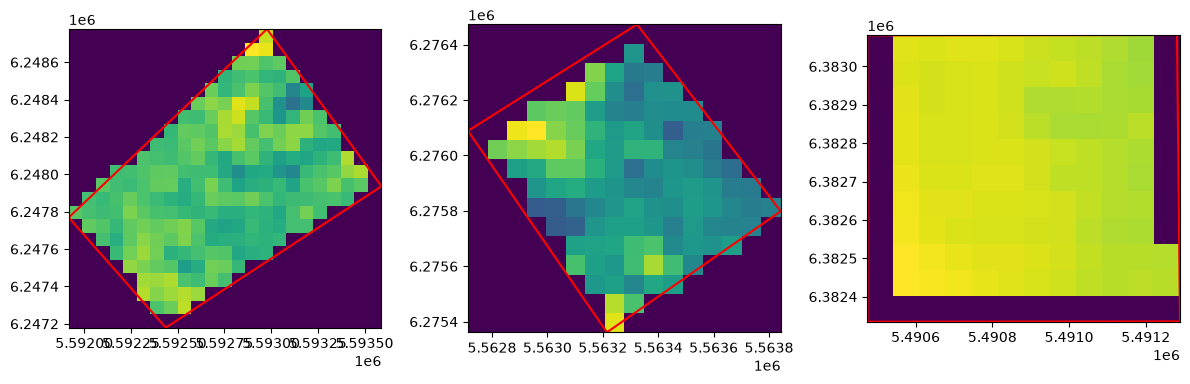

In [75]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4), tight_layout=True)

for idx, row in gpd_samples_rep.iterrows():
    #print(row.geometry.bounds)
    minx, miny, maxx, maxy = row.geometry.bounds
    plot_extent = (minx, maxx, miny, maxy)
    
    scene_mask, mask_transform = mask(dataset=scene_test, shapes = [row.geometry], crop = True)
    ax[idx].imshow(scene_mask[0], cmap='viridis', extent = plot_extent)
    
    gpd.GeoSeries([row.geometry]).plot(ax=ax[idx], edgecolor='red', linewidth=1.5, facecolor='none')
    

In [76]:
rdc(TIF_PATH, SAMPLES_PATH, SAMPLES_COL, LIST_PROBS)

/home/franco-barrionuevo/Documents/GitHub/MAIE_devs_pub/SAR/Mercedes/TP4 Filtros/radiometric_uncertainty/radunc.py:115: UserWarning: CRS mismatch: samples CRS (EPSG:4326) does not match raster CRS (PROJCS["unnamed",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",-90],PARAMETER["central_meridian",-60],PARAMETER["scale_factor",1],PARAMETER["false_easting",5500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]). Reprojecting samples to match raster.
  gdf_samples = read_check_vector(tif_path, samples_path)


,Sample,Mean,Std,ENL,Rad. Unc. 50 [dB],Real. Prob. 50 [%],Rad. Unc. 90 [dB],Real. Prob. 90 [%],Rad. Unc. 95 [dB],Real. Prob. 95 [%]
0,forestacion3,0.088048,0.011379,59.875057,0.38,50.09,0.93,90.10,1.11,95.05
1,juncal4,0.575376,0.156576,13.503689,0.80,49.84,1.98,89.96,2.39,95.03
2,laguna5,0.005134,0.000184,774.556641,0.11,51.91,0.26,90.42,0.31,95.29


In [4]:
ENL = 4

(<Figure size 1000x400 with 1 Axes>,
 <Axes: title={'center': 'Probability vs Radiometric Uncertainty - ENL:4'}, xlabel='Radiometric Uncertainty (dB)', ylabel='Probability (%)'>)

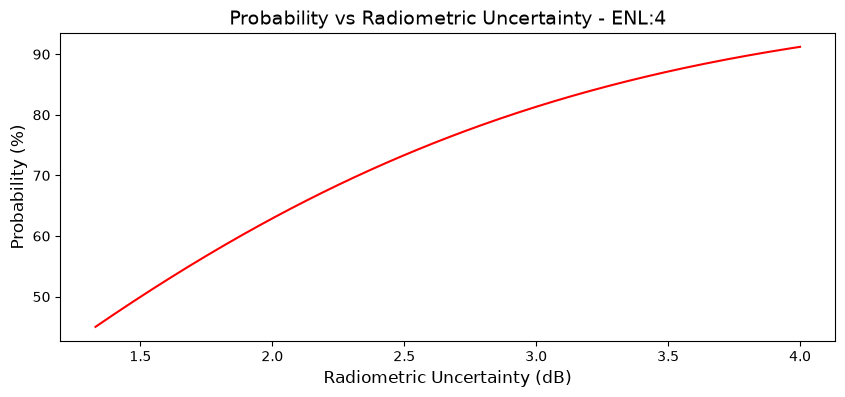

In [5]:
prb(ENL)